In [1]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
import numba as nb
import time
import importlib
import json
import argparse
import h5py
from matplotlib import pyplot as plt
from datetime import datetime as dt

from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils

from scipy.optimize import minimize,check_grad,least_squares
from scipy.ndimage import median_filter
from scipy.ndimage import binary_opening, binary_closing, label
from skyfield.api import load, wgs84

import helper_finetiming as hf
import figures as fgs

sys.path.append(os.path.expanduser('~'))

BDC is using numpy
BDC is using numpy


In [ ]:
#VIS STUFF
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

def get_vis(data,satID,freqs, pstart,pend,antpos,ant_idxs,tle_path, T_SPECTRA,osamp,acclen):   
    n_blines = len(ant_idxs)*(len(ant_idxs)-1)//2
    multi_vis = np.zeros((n_blines, data.shape[2]//acclen, data.shape[3]), dtype='complex64', order='c')
    print("multi_vis shape", multi_vis.shape)

    bl_proc=0
    for i in range(len(ant_idxs)):
            for j in range(i+1, len(ant_idxs)):
                ai = ant_idxs[i]
                aj = ant_idxs[j]
                a1_coords=antpos[ai]
                a2_coords=antpos[aj]
                dly = outils.get_sat_delay(
                                    a1_coords,
                                    a2_coords,
                                    tle_path,
                                    pstart,
                                    int(pend - pstart)+2,
                                    satID,
                                    altaz=False
                                )
                delay = np.interp(
                    np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(pend - pstart)+2), dly
                )
                spec1=data[ai,0,:,:]
                spec2=data[aj,0,:,:]
                spec2_phased = np.empty_like(spec2)
                # print("spec2", spec2_phased.shape)
                # print(spec2_phased.flags)
                spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
                Vxx = xcorr_avg(spec1,spec2_phased,acclen)
                spec1=data[ai,1,:,:]
                spec2=data[aj,1,:,:]
                spec2_phased = np.empty_like(spec2)
                spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
                Vyy = xcorr_avg(spec1,spec2_phased,acclen)
                multi_vis[bl_proc,:,:] = (Vxx+Vyy)/2
                bl_proc+=1
                print("done", ai,aj,".Processed",bl_proc, "baselines")
    return multi_vis

In [3]:
#FITTING STUFF
@nb.njit()
def func(tau_t, data, freq, weights):
    ''' 
    Get residuals for given tau at single time sample, for all blines

    Notes:
    - we set the reference antenna to zero delay: all other ants are with respect to it
    - therefore tau_t has length nant-1
    - residuals is 1D, and splits real and imag residuals up for fitting
    - convention is that timing difference is ai-aj
    '''
    # for one time sample
    nant=len(tau_t) + 1
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    residuals = np.zeros((2 * n_eval,), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * freq[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                if weights.ndim==2:
                    w = weights[blnum,j]
                else:
                    w = weights[blnum]
                if ai == 0:
                    pred=(-two_pi_nu * tau_t[aj - 1])  # ant 0 is refant
                else:
                    pred=(two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1]))
                y = np.exp(1j * pred) - np.exp(1j*data[rowidx])
                residuals[rowidx] = w * np.real(y)
                residuals[rowidx + n_eval] = w * np.imag(y)
                blnum += 1
    return residuals

@nb.njit()
def jac(tau_t, data, freq, weights):
    '''
    Get the Jacobian for given tau at single time sample, for all blines

    Notes:
    - Antenna 0 is the reference so its delay is zero
    - therefore tau_t has length nant-1
    '''
    nant=7
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    J = np.zeros((2 * n_eval, nant-1), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * freq[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                if weights.ndim==2:
                    w = weights[blnum,j]
                else:
                    w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, aj - 1] = -im
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, ai - 1] = re
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, ai - 1] = im
                    J[rowidx + n_eval, aj - 1] = -im
                blnum += 1
    return J

In [4]:
#DATA MANIPULATION

def get_mask(vis, tol=1.5): 
    angle = np.angle(vis[:,:,:])
    _, ntimes, nchans = vis.shape

    fig, ax = plt.subplots(2,2,sharex=True)
    fig.set_size_inches(10, 10)
    img=ax[0,0].imshow(angle[0,:,:],aspect='auto',interpolation='none',cmap='RdBu')
    ax[0,0].set_title(f'Angles for Bline Index 0')

    x = np.arange(ntimes)
    residuals = np.zeros((n_blines, ntimes, nchans),dtype='float64')
    blnum=0
    for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            for k in range(angle.shape[2]):
                m, c = np.polyfit(x, angle[blnum,:,k], 1)
                residuals[blnum, :, k] = angle[blnum,:,k] - (m*x + c)
            blnum+=1

    mad = np.median(np.abs(residuals[:,:,:]), axis=0)
    img = ax[0,1].imshow(mad, aspect='auto',interpolation='none')
    ax[0,1].set_title('MAD across all blines')
    fig.colorbar(img, ax=ax[0,1])

    mask = mad > tol
    img = ax[1,0].imshow(mask, aspect='auto',interpolation='none')
    ax[1,0].set_title('Raw Mask all Blines')

    mask = binary_closing(mask, structure=np.ones((7,1)))
    mask_pulse = np.zeros_like(mask, dtype=bool)
    n_time, n_chan = mask.shape

    for ch in range(n_chan):
        labeled, n_features = label(mask[:, ch])
        for i in range(1, n_features + 1):
            # indices of this block
            block = (labeled == i)
            if block.sum() >= 5:
                mask_pulse[:, ch][block] = True

    img = ax[1,1].imshow(mask_pulse, aspect='auto',interpolation='none')
    ax[1,1].set_title('Filtered Mask all blines')
    return mask_pulse


def get_thermal_noise(vis, ant_idxs, mask=None):

    fig,ax = plt.subplots(7,3, constrained_layout=True)
    fig.set_size_inches(10,20)
    ax=np.ravel(ax)
    plt.suptitle(f"stokes I (phase), int. time {T_SPECTRA*acclen:4.2f}s")
    nblines, ntimes, nchans = vis.shape

    thermal_noise = np.zeros((nblines, ntimes),dtype='float64')
    vis_noise = np.zeros((nblines, ntimes),dtype='float64')
    x_all  = np.arange(nchans)
    angle = np.angle(vis)
    blnum = 0
    for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            a = angle[blnum, :, :].copy()  # (ntimes, nchan)

            if mask is None:
                a2=np.unwrap(a,axis=1)
                for k in range(a2.shape[0]):
                    m, c = np.polyfit(x_all, a2[k,:], 1)
                    residual = a2[k,:] - (m*x_all + c)
                    # sigma_phi = np.sqrt(np.mean(residual**2))
                    sigma_phi = np.std(np.angle(np.exp(1j*residual)))
                    thermal_noise[blnum,k] = sigma_phi
                    vis_noise[blnum,k] = np.std(np.cos(residual))
                img=ax[blnum].imshow(np.angle(vis[blnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
                cbar=plt.colorbar(img,ax=ax[blnum])
            else:
                #iterate over all time chunks
                for k in range(ntimes):
                    good_idx = ~mask[k, :]
                    if good_idx.sum() < 2:
                        #print(f"Too few points to fit for time {k}")
                        thermal_noise[blnum, k] = 1
                        continue

                    elif good_idx.sum() < 10:
                        #print(f'Very few channels time {k}')
                        thermal_noise[blnum, k] = 1
                        continue

                    # unwrap and fit linear phase ramp (only for 'good' data)
                    phase_good = np.unwrap(a[k, good_idx])
                    x = np.arange(a.shape[1])[good_idx]
                    y = phase_good
                    m, c = np.polyfit(x, y, 1)

                    # get noise on ramp (only for 'good' data)
                    residual = y - (m * x + c)
                    sigma_phi = np.std(np.angle(np.exp(1j * residual)))  # circular std
                    vis_noise_val = np.std(np.cos(residual))

                    thermal_noise[blnum, k] = sigma_phi
                    vis_noise[blnum, k] = vis_noise_val

                # plot masked arrays
                a_masked = np.ma.masked_where(mask, np.angle(vis[blnum, :, :]))
                img = ax[blnum].imshow(a_masked, aspect='auto', interpolation='none', cmap='RdBu')
                plt.colorbar(img, ax=ax[blnum])
            blnum+=1
    return thermal_noise

def find_lowest_noise(noise, window_size=120):
    nblines, ntimes = noise.shape
    min_noise = float('inf')
    best_start_idx = -1

    for t in range(ntimes - window_size + 1):
        # Slice over time, keep all baselines
        window = noise[:, t:t + window_size]
        
        # Collapse both dimensions → single statistic
        window_noise = np.median(window)  # or np.mean(window)
        
        if window_noise < min_noise:
            min_noise = window_noise
            best_start_idx = t

    return best_start_idx, best_start_idx+window_size


In [5]:
#LINEAR ALGEBRA FITTING STUFF
@nb.njit()
def symmetrize(A):
    nr, nc = A.shape
    for i in range(nr):
        for j in range(i, nc):
            A[j, i] = A[i, j]

def get_grammian(nant):
    nbl = (nant - 1) * nant // 2
    Ag = np.zeros((nbl, nant - 1), dtype="float64")
    b = 0
    for i in range(nant):
        for j in range(i + 1, nant):
            # print(i,j)
            if i == 0:
                Ag[b, j - 1] = -1
            else:
                Ag[b, i - 1] = 1
                Ag[b, j - 1] = -1
            b += 1
    return Ag


def get_AtA_Atd(data, Ag, noise_var, nu, nant, nfreq, ntime, fit_constant=True):
    # data is ntime, nfreq, nbl, C-major
    nparam = (nant - 1) * ntime
    if fit_constant:
        nparam += nant - 1
    nbl = (nant - 1) * nant // 2
    npertime = nfreq * nbl
    myAtA = np.empty((nparam, nparam), dtype="float64")
    myAtd = np.empty((nparam,), dtype="float64")
    myAtA[:] = 0.0
    myAtd[:] = 0.0
    two_pi = 2 * np.pi
    Snu2 = np.sum(nu**2) * two_pi**2
    Snu = np.sum(nu) * two_pi
    print("Snu", Snu, "Snu2", Snu2)
    bs = nant - 1  # block size
    # print("nant", nant, "nbl", nbl, "ntime", ntime, "nfreq", nfreq, "bs", bs)
    # print("d shape", d.shape)
    # print("n pertime", npertime)
    for i in range(ntime):
        Agw = Ag / noise_var[i, :][:, None]  # whitened A
        myAtA[i * bs : (i + 1) * bs, i * bs : (i + 1) * bs] = Ag.T @ Agw * Snu2
        if fit_constant:
            myAtA[i * bs : (i + 1) * bs, ntime * bs :] = Ag.T @ Agw * Snu
            myAtA[ntime * bs :, ntime * bs :] += Ag.T @ Agw * nfreq
        for j in range(nfreq):
            idx = i * npertime + j * nbl
            vec = Agw.T @ data[i, j, :]
            myAtd[i * bs : (i + 1) * bs] += two_pi * nu[j] * vec
            if fit_constant:
                myAtd[-bs:] += vec
    symmetrize(myAtA)
    return myAtA, myAtd

# START OF CODE

In [6]:
path_config = "/home/thomasb/albatros_analysis/scripts/orbcomm/config/config_batch1.json"

with open(path_config, "r") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
    antpos.append(details["coordinates"])
print(antpos)

batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
osamp = config['correlation']['osamp']
acclen = config['correlation']['new_acclen']

T_SPECTRA = 4096/250e6 * osamp
print(T_SPECTRA)

[[79.41716147, -90.76723869, 187.9577], [79.41719805, -90.75873919, 183.0684], [79.38845641, -91.01920296, 25.1938], [79.41830257, -90.66739545, 59.6242], [79.39798424, -90.79984241, 41.699], [79.41147412, -90.69526613, 31.6314], [79.44375769, -90.71820263, 414.9131]]
0.001048576


In [7]:
path_batch = f'/scratch/thomasb/batch_{batch_start_ts}'

fname_pulses = "data/pulses.json"
path_pulses = os.path.join(path_batch, fname_pulses)

fname_cutter_discrep = "data/cutting_discrep.json"
path_cutter_discrep = os.path.join(path_batch, fname_cutter_discrep)

fname_map = 'timing_discrepancies/times_all.json'
path_map = os.path.join(path_batch, fname_map)

In [8]:
with open(path_pulses, "r") as f_pulses:
        pulse_list = json.load(f_pulses)

with open(path_cutter_discrep, "r") as f_cutter:
        dict_cutter_discrep = json.load(f_cutter)

with open(path_map, "r") as f_map:
        map_dict = json.load(f_map)

In [9]:
taus_fitted_all = {}
overflow = False

ant_idxs = [0, 1, 2, 3, 4, 5, 6]
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
nant_used = len(ant_idxs)
n_blines = len(ant_idxs)*(len(ant_idxs)-1)//2

In [10]:
idx_pulse = 3

#extract from pulses json
pulse = pulse_list[idx_pulse]
print(pulse)

pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']
print('detection channel', chan_det)

assert satID in {59051, 57166, 28654,25338,33591}
if satID in {59051, 57166}:
    masking = False
if satID in {28654,25338,33591}:
    masking=True

print('masking:', masking)
if chan_det%2 == 0:
    chans_old = np.arange(chan_det-2, chan_det+2) + 1834
else:
    chans_old = np.arange(chan_det-1, chan_det+3) + 1834

print(chans_old)

{'antenna': 'Antenna 2', 'sat': 57166, 'channel': 3, 't_start': 1753137712, 't_end': 1753138105, 'len': 393, 'start_specnum': 1466693883}
detection channel 3
masking: False
[1836 1837 1838 1839]


In [11]:
fname_data = f"data_raw_osamp=64_start={pulse_start_ts}_end={pulse_end_ts}_chans={chans_old[0]}:{chans_old[-1]}.npy"

#extract from discrep cutter (to get channels)
cut_discrep = dict_cutter_discrep[fname_data]

chan_new_start, chan_new_end  = cut_discrep["cut_chans"]
chans_new = np.arange(chan_new_start, chan_new_end)
nchans = len(chans_new)
print(nchans)
print(chans_new)

freqs = (chans_new/64 + chans_old[0])*250e6/4096
freqs = 250e6-freqs
freqs_normalized = freqs/1e9

data1 = np.load(os.path.join(path_batch, 'data', fname_data))
data1 = data1[:, :, :, chans_new]
nant = data1.shape[0]
print(data1.shape)
print(nant)

80
[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81]
(7, 2, 374784, 80)
7


In [12]:
#extract from mapping json
# map = map_dict[fname_data]
# pulse_start_spec = map["start_spectrum"]
pulse_start_spec = 1466693883
print('starting specnum', pulse_start_spec)


UTC_per_spec = map_dict['fit']['UTC_per_spec']
UTC_offset = map_dict['fit']['UTC_offset']
# UTC_per_spec = 1.638400946109685e-05
# UTC_offset = 1753200128.469018

pstart1 = UTC_per_spec*pulse_start_spec + UTC_offset
print(pstart1)

tle_path = outils.get_tle_file(pstart1, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

starting specnum 1466693883
1753137712.5408115


In [13]:
#using newly computed stuff
print(data1.shape)

(7, 2, 374784, 80)


In [14]:
vis1 = get_vis(data1,satID,freqs,pstart1,pulse_end_ts,antpos,ant_idxs,tle_path,T_SPECTRA,osamp,acclen)

multi_vis shape (21, 366, 80)
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.0864102840423584


done 0 1 .Processed 1 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.0826258659362793
done 0 2 .Processed 2 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.08153486251831055
done 0 3 .Processed 3 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.08733558654785156
done 0 4 .Processed 4 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.08189940452575684
done 0 5 .Processed 5 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.08140683174133301
done 0 6 .Processed 6 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.0824577808380127
done 1 2 .Processed 7 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.08684468269348145
done 1 3 .Processed 8 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.08156132698059082
done 1 4 .Processed 9 baselines
catalog #57166 epo

In [15]:
#make adaptive. while loop maybe? needs a minimum number of real points.
if masking:
    mask1 = get_mask(vis1, tol=1.8)
else:
    mask1 = None

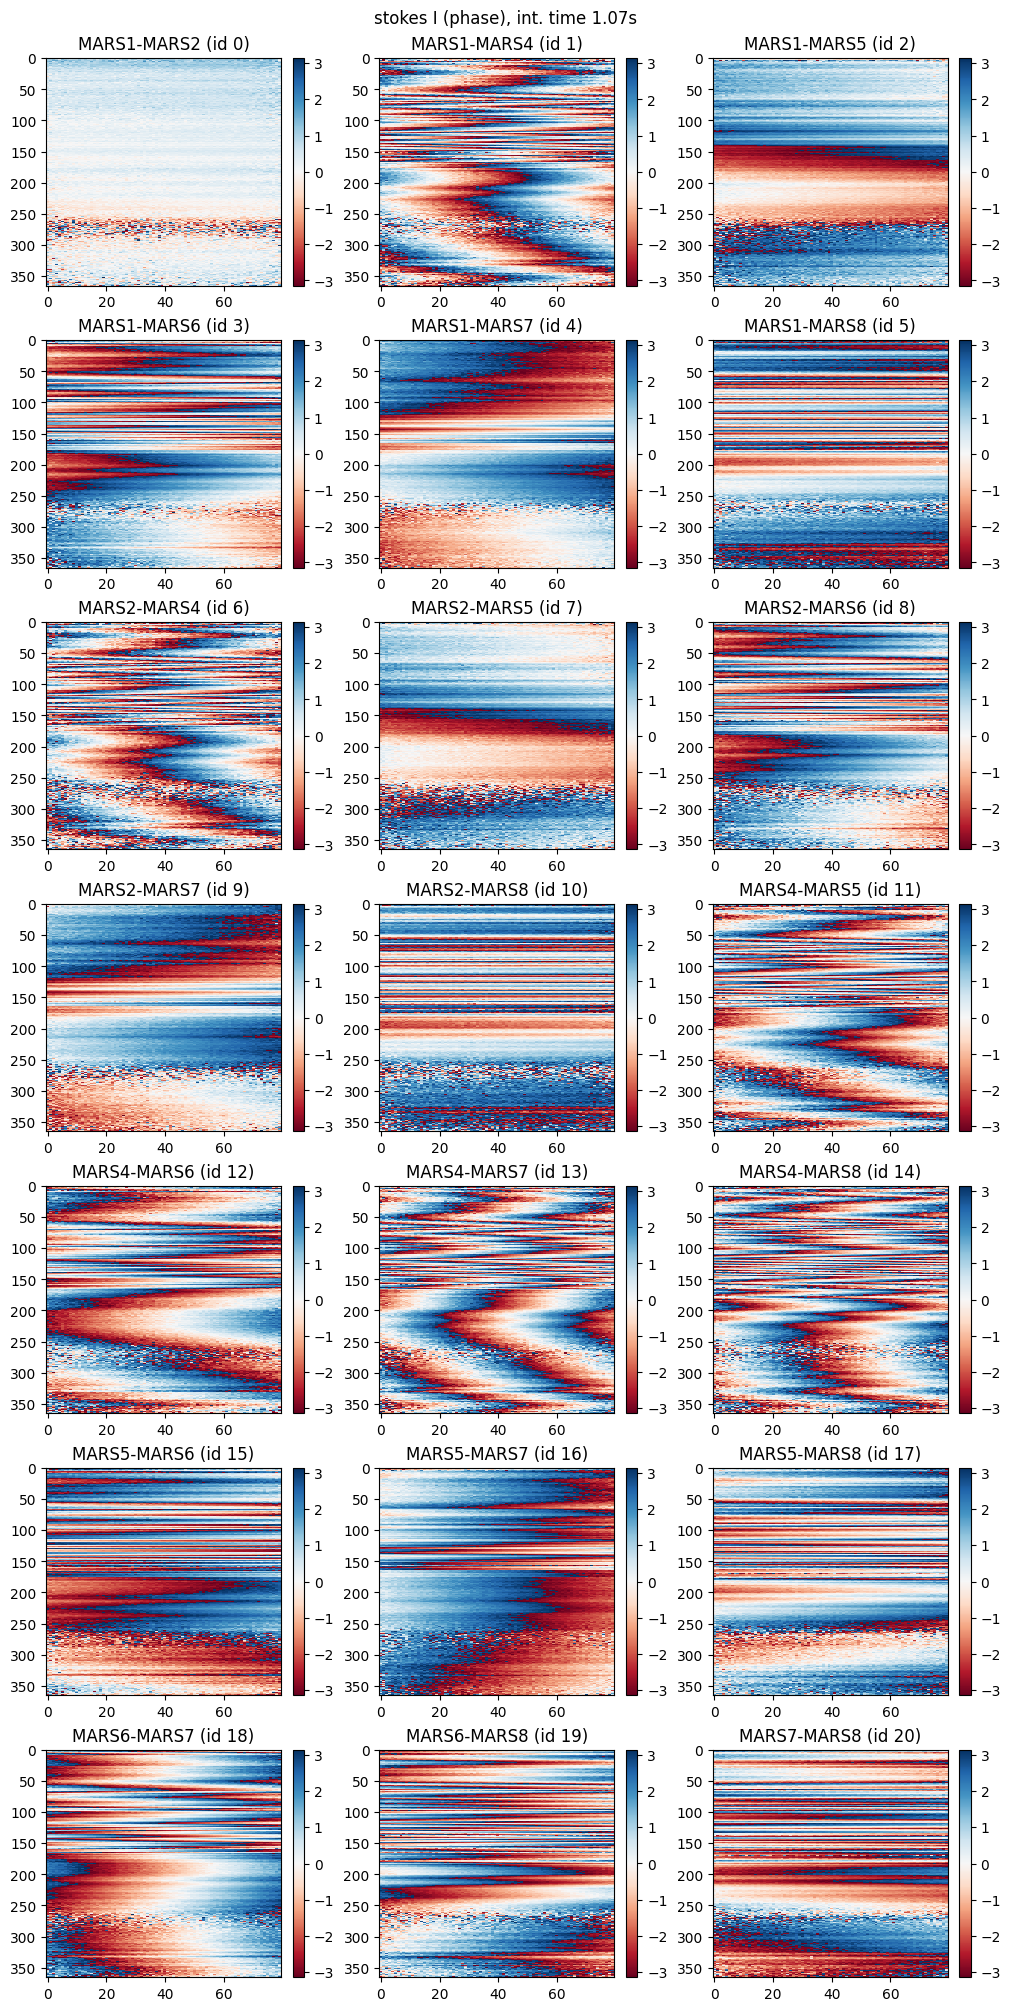

In [16]:
thermal_noise1 = get_thermal_noise(vis1,ant_idxs,mask=mask1)

(21, 366)


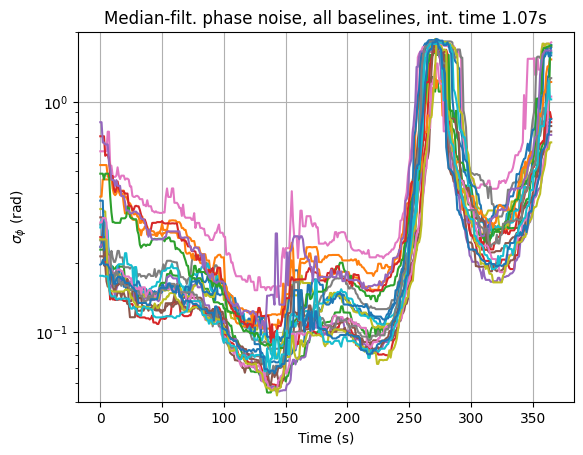

In [17]:
print(thermal_noise1.shape)
for bl in range(n_blines):
    plt.semilogy(median_filter(thermal_noise1[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

In [18]:
start_cut, end_cut = find_lowest_noise(thermal_noise1)


#start_cut, end_cut = 10, 130

print(start_cut, end_cut)
start_spectra, end_spectra = start_cut*acclen, end_cut*acclen

112 232


In [19]:
pulse_start_spec_cut = pulse_start_spec+start_spectra*64
pstart2 = UTC_per_spec*pulse_start_spec_cut + UTC_offset
print(pstart2)

data2 = data1[:,:,start_spectra:end_spectra,:]
print(data2.shape)

1753137832.7998009
(7, 2, 122880, 80)


In [20]:
vis2=get_vis(data2,satID,freqs,pstart2,pulse_end_ts,antpos,ant_idxs,tle_path,T_SPECTRA,osamp,acclen)
nblines, ntimes, nchans = vis2.shape
print(vis2.shape)

multi_vis shape (21, 120, 80)
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.05832648277282715
done 0 1 .Processed 1 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.062474966049194336
done 0 2 .Processed 2 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.05788683891296387
done 0 3 .Processed 3 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.05781984329223633


done 0 4 .Processed 4 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.060849905014038086
done 0 5 .Processed 5 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.06270003318786621
done 0 6 .Processed 6 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.06152534484863281
done 1 2 .Processed 7 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.06056475639343262
done 1 3 .Processed 8 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.05953860282897949
done 1 4 .Processed 9 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.06206679344177246
done 1 5 .Processed 10 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.05783963203430176
done 1 6 .Processed 11 baselines
catalog #57166 epoch 2025-07-21 22:21:37 UTC
one delay prediction: 0.057648658752441406
done 2 3 .Processed 12 baselines
catalog #57

In [21]:
if masking:
    mask2 = get_mask(vis2, tol=1.7)
else:
    mask2 = None

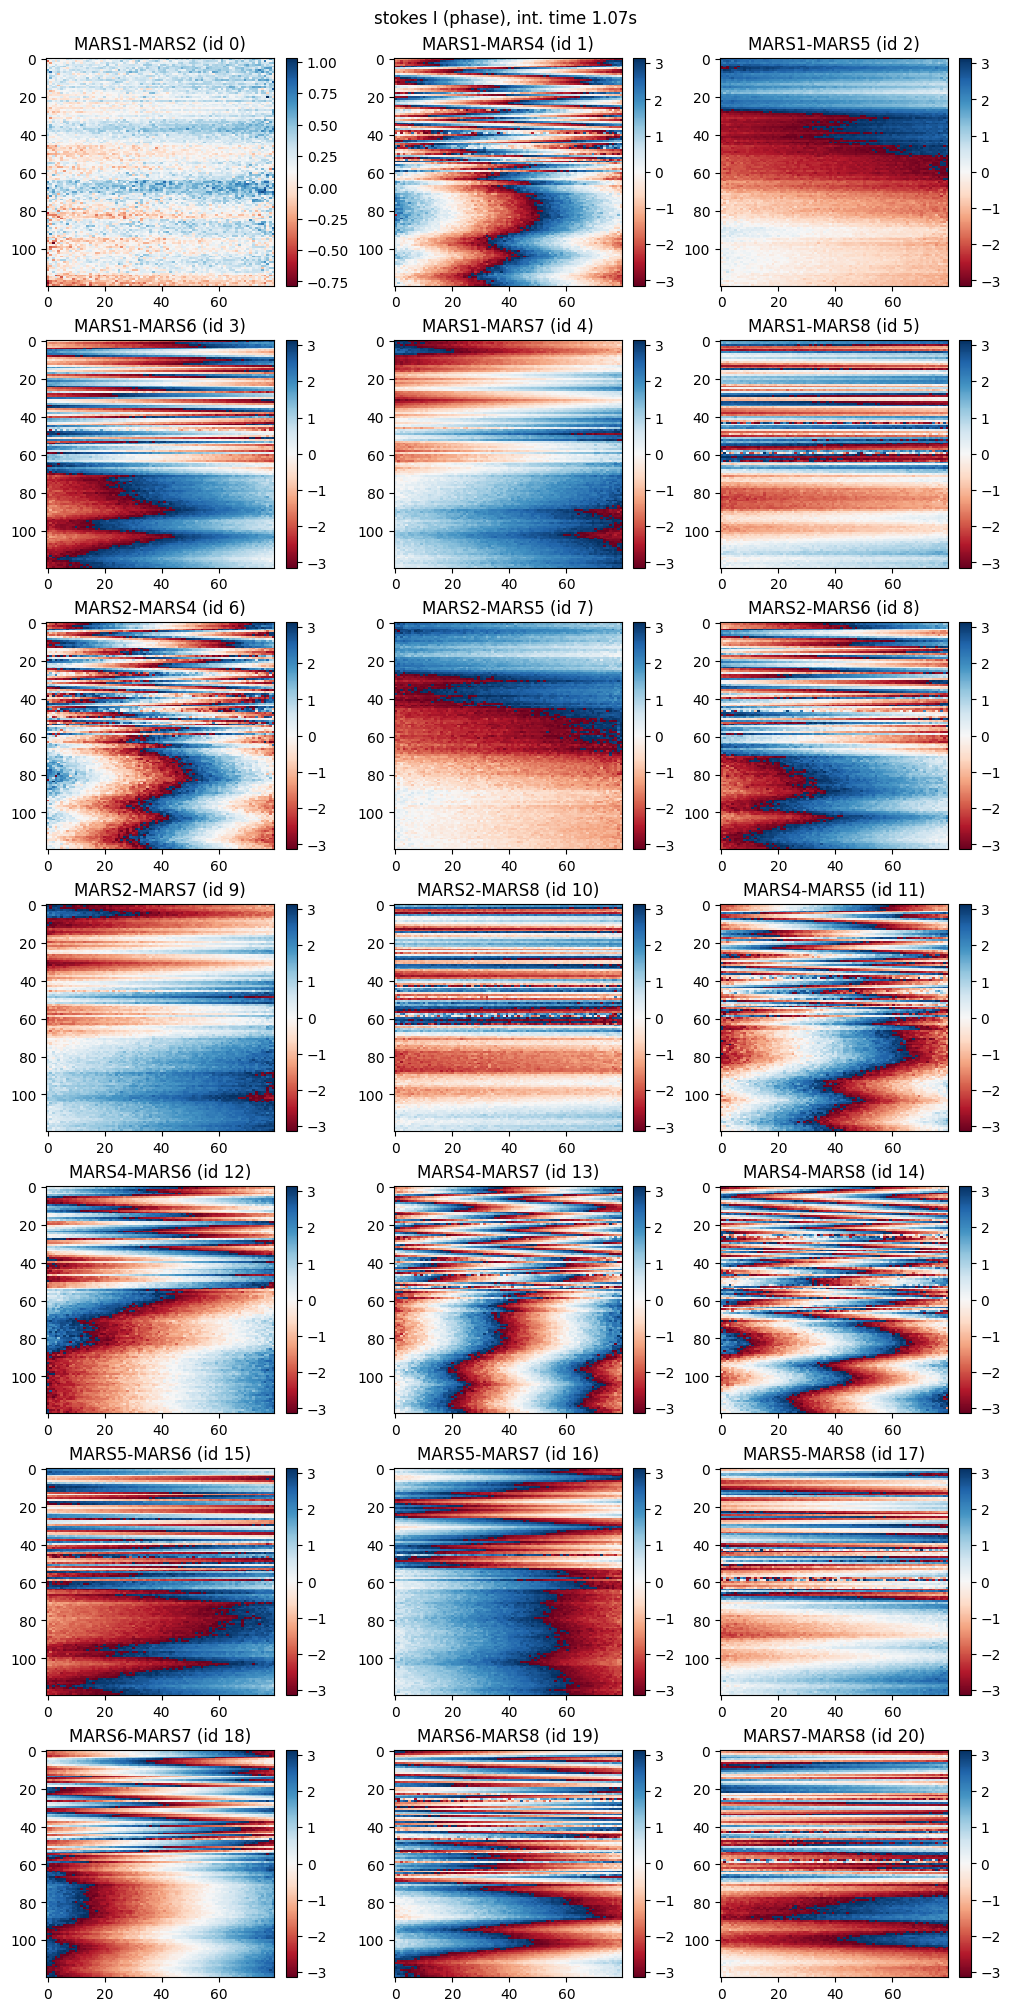

In [22]:
thermal_noise2 = get_thermal_noise(vis2, ant_idxs, mask=mask2)

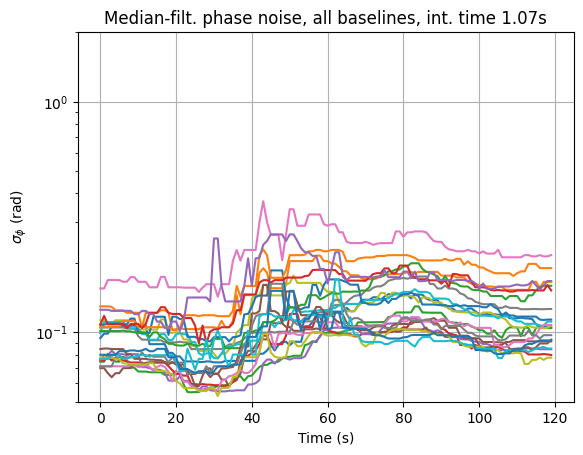

In [23]:
for bl in range(n_blines):
    plt.semilogy(median_filter(thermal_noise2[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

(21, 80)


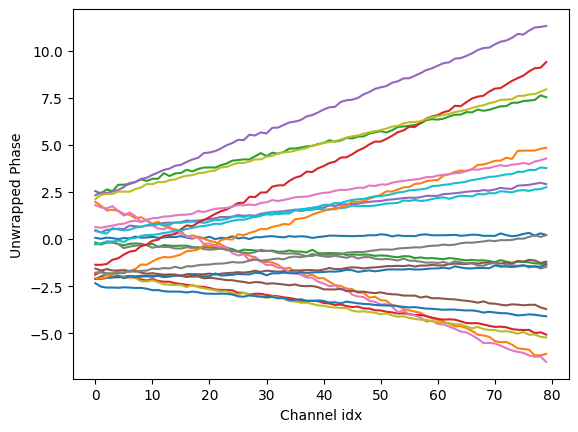

In [26]:
#get an initial guess for tau
avg_multi_vis = np.mean(vis2[:, 80:90, :], axis=1)
nbl = avg_multi_vis.shape[0]
print(avg_multi_vis.shape)

avg_multi_phase = np.unwrap(np.angle(avg_multi_vis), axis = 1)
#avg_multi_phase = avg_multi_phase - avg_multi_phase[:, 39][:, None]
for i in range(nbl):
    plt.plot(avg_multi_phase[i,:])
plt.xlabel('Channel idx')
plt.ylabel('Unwrapped Phase')

#get that noise by fitting a line and getting std of residuals
noise_matrix_avg = np.zeros((1,nbl),dtype='float64')
x = freqs
for bl in range(nbl):
    y = avg_multi_phase[bl,:]
    m, c = np.polyfit(x,y, 1)
    residual = y - (m*x + c)
    noise_matrix_avg[0,bl] = np.std(residual)
# print(noise_matrix_avg)

In [27]:
#can now just fit linearly using normal equations
data_matrix = avg_multi_phase.T.reshape(1,nchans,nbl)

Ag = get_grammian(nant)
print(data_matrix.shape)

AtA2,Atd2 = get_AtA_Atd(data_matrix,
                        Ag,
                        noise_matrix_avg**2,
                        freqs_normalized,
                        nant,
                        nchans,  
                        1,
                        fit_constant=True
                        )

AtA_inv2 = np.linalg.inv(AtA2)

mfit2 = AtA_inv2 @ Atd2

# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
taus_guess0 = mfit2[:1 * bs]
phi_guess0 = mfit2[1 * bs:]
errs_guess0 = np.sqrt(np.diag(AtA_inv2))
print(taus_guess0)
print(phi_guess0)
print(errs_guess0)

(1, 80, 21)
Snu 69.3160377990881 Snu2 60.05891523378247
[   441.8484828  -17289.03843838  -2354.15274308  -6751.28564712
   5312.46372005   1894.83938722]
[ -383.02057431 14984.60450336  2040.47230015  5852.67822263
 -4604.69496544 -1640.56857037]
[19.08382315 24.12616869 17.39357275 16.77673972 16.54232625 16.49381259
 16.5351878  20.90413053 15.07066952 14.53621424 14.33310658 14.2910719 ]


21


/tmp/ipykernel_3240358/1350451251.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


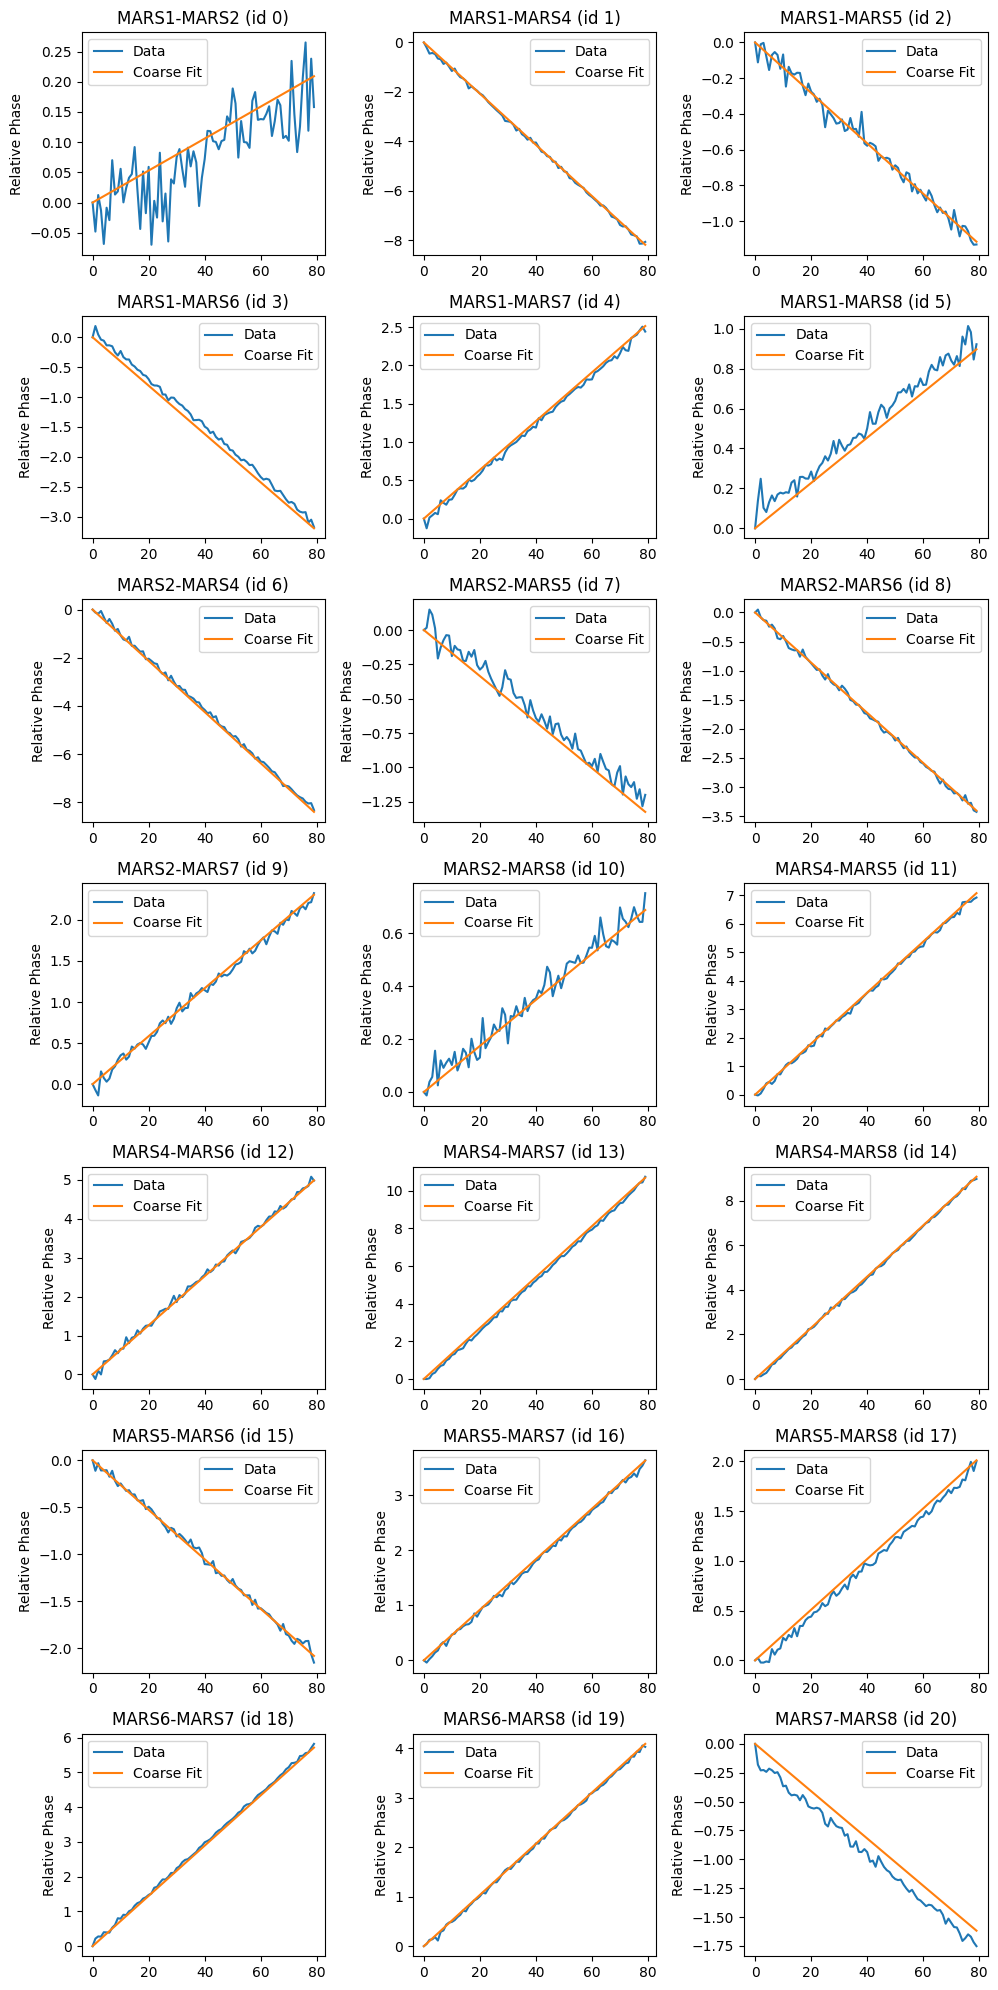

In [28]:
#test to see
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(7,3, constrained_layout=True)
fig.set_size_inches(10,20)
ax=np.ravel(ax)

blnum=0
print(n_blines)
x = np.arange(nchans)
phased_vis = np.empty_like(vis2[:,:,:])
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            if i==0:
                tau1=0
            else:
                tau1 = taus_guess0[i-1]
            tau2 = taus_guess0[j-1]
            rel_delay = tau1-tau2
            phase_bline = avg_multi_phase[blnum, :]
            phase_pred = np.unwrap(np.angle(np.exp(2j*np.pi*rel_delay*freqs_normalized)))
            ax[blnum].plot(phase_bline - phase_bline[0], label='Data')
            ax[blnum].plot(phase_pred - phase_pred[0], label='Coarse Fit')
            ax[blnum].set_ylabel('Relative Phase')
            ax[blnum].legend()
            blnum+=1
plt.tight_layout()

noise var shape (21, 120)
data_matrix shape (120, 80, 21)
weight_matrix shape (120, 21)
noise matrix shape (120, 21)
ntimes 120
nchans 80
nblines 21
nant used: 7


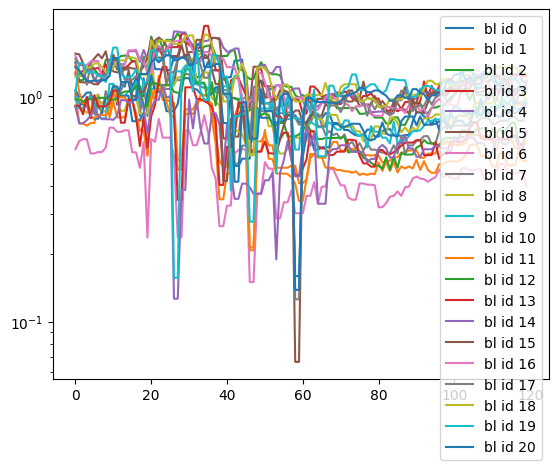

In [29]:
# get noise and fit for each timestamp 
noise_var = median_filter(thermal_noise2[:,:],3,axes=1)**2   #why a median filter of just 3??
print('noise var shape', noise_var.shape)

weights = np.sqrt(np.size(noise_var)/noise_var/np.sum(1/noise_var))
angle = np.angle(vis2)

if masking:
    weights = np.tile(weights[:, :, None], (1, 1, nchans))
    weights = np.where(mask2[None, :, :], 0, weights)
    weight_matrix = weights.transpose(1,2,0).copy() #do same for weights so it follows
    phase_unwrapped = angle

    for bl in range(n_blines):
        #max is fine since weights either zero or depend on full channel thermal noise
        plt.semilogy(np.max(weights[bl,:, :], axis=1),label=f'bl id {bl}')
    plt.legend()

else:
    phase_unwrapped = angle
    weight_matrix = weights.T.copy()
    for bl in range(n_blines):
        plt.semilogy(weights[bl,:],label=f'bl id {bl}')
    plt.legend()

#make baseline fastest moving axis for convenience
data_matrix = phase_unwrapped.transpose(1,2,0).copy()
noise_matrix = noise_var.T.copy()
print('data_matrix shape', data_matrix.shape)
print('weight_matrix shape', weight_matrix.shape)
print('noise matrix shape', noise_matrix.shape)

# make frequencies order 1 for fitting purposes
freqs_normalized = freqs.copy()/1e9

# set up some global variables
assert ntimes == data_matrix.shape[0]
assert nchans == data_matrix.shape[1]
assert nblines == data_matrix.shape[2]
assert nant_used == len(ant_idxs) 
print('ntimes', ntimes)
print('nchans', nchans)
print('nblines', nblines)
print("nant used:", nant_used)

(120, 80, 21)
-17289.038438379765


Text(0.5, 0.98, 'Red Guess of -17289 ns for ant idx MARS 4')

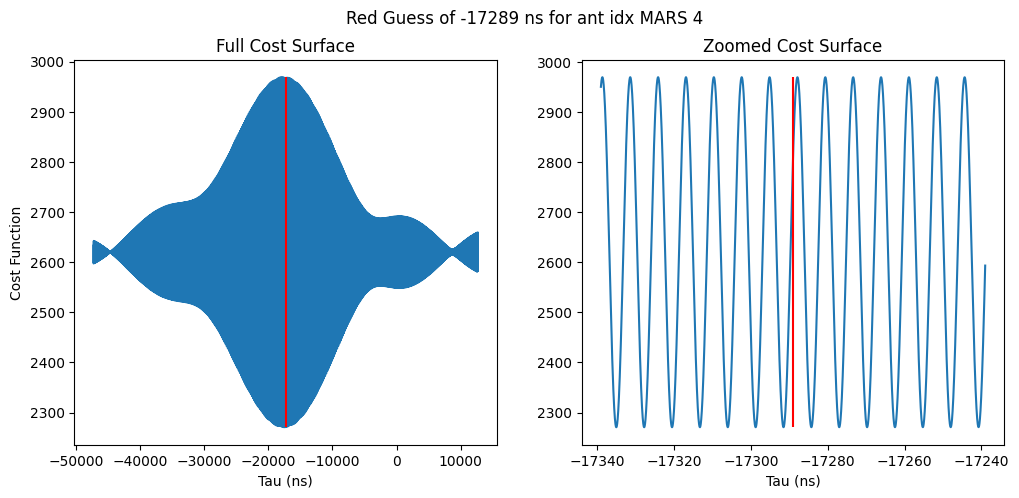

In [30]:
antmap = ['MARS 2', 'MARS 4', 'MARS 5', 'MARS 6', 'MARS 7', 'MARS 8']

antidx = 1
timeidx = 5
N = 10001
print(data_matrix.shape)
print(taus_guess0[antidx])
taus_trial1, taus_trial2 = np.tile(taus_guess0, (N, 1)), np.tile(taus_guess0, (N, 1))
taus_trial1[:, antidx] = np.linspace(-30000, 30000, N) + taus_guess0[antidx]
taus_trial2[:,antidx] = np.linspace(-50, 50, N) + taus_guess0[antidx]

cost1, cost2 = np.zeros(N), np.zeros(N)
for i in range(N):
    cost1[i] = np.sum(func(taus_trial1[i], data_matrix[timeidx,:,:].ravel(), freqs_normalized, weights)**2)
    cost2[i] = np.sum(func(taus_trial2[i], data_matrix[timeidx,:,:].ravel(), freqs_normalized, weights)**2)

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].plot(taus_trial1[:,antidx], cost1)
ax[0].vlines(x=taus_guess0[antidx], ymin = min(cost1), ymax=max(cost1), color='r')
ax[0].set_title('Full Cost Surface')
ax[0].set_xlabel('Tau (ns)')
ax[0].set_ylabel('Cost Function')

ax[1].plot(taus_trial2[:,antidx], cost2)
ax[1].vlines(x=taus_guess0[antidx], ymin = min(cost2), ymax=max(cost2), color='r')
ax[1].set_title('Zoomed Cost Surface')
ax[1].set_xlabel('Tau (ns)')

fig.suptitle(f'Red Guess of {int(taus_guess0[antidx])} ns for ant idx {antmap[antidx]}')

starting guess: [   441.8484828  -17289.03843838  -2354.15274308  -6751.28564712
   5312.46372005   1894.83938722]
done tt=0, time = 0.004
done tt=1, time = 0.001
done tt=2, time = 0.001
done tt=3, time = 0.001
done tt=4, time = 0.001
done tt=5, time = 0.001
done tt=6, time = 0.001
done tt=7, time = 0.001
done tt=8, time = 0.001
done tt=9, time = 0.001
done tt=10, time = 0.001
done tt=11, time = 0.001
done tt=12, time = 0.001
done tt=13, time = 0.001
done tt=14, time = 0.002
done tt=15, time = 0.001
done tt=16, time = 0.002
done tt=17, time = 0.001
done tt=18, time = 0.002
done tt=19, time = 0.002
done tt=20, time = 0.002
done tt=21, time = 0.001
done tt=22, time = 0.001
done tt=23, time = 0.002
done tt=24, time = 0.001
done tt=25, time = 0.001
done tt=26, time = 0.001
done tt=27, time = 0.002
done tt=28, time = 0.002
done tt=29, time = 0.001
done tt=30, time = 0.002
done tt=31, time = 0.003
done tt=32, time = 0.002
done tt=33, time = 0.001
done tt=34, time = 0.001
done tt=35, time = 0

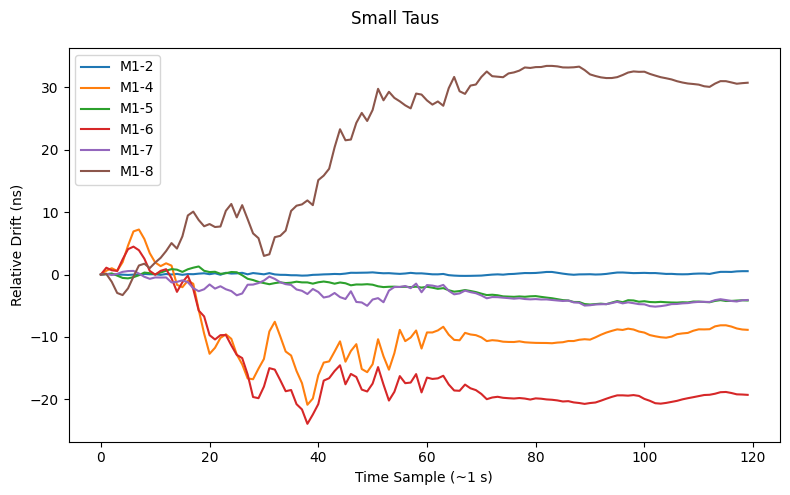

In [66]:
# array of fitted taus for each time, for each (non-reference) antenna
taus_fitted = np.zeros((ntimes,nant_used-1),dtype='float64')

# make some guess about fitted taus (for one sample time)
taus_guess = taus_guess0
print('starting guess:', taus_guess0)

for tt in range(ntimes):
    ydata = data_matrix[tt,:,:].ravel()
    if masking:
        weights = weight_matrix[tt,:,:]
    else:
        weights = weight_matrix[tt,:]
    t1=time.time()

    tau_fit_params = least_squares(func, taus_guess, args=(ydata, freqs_normalized, weights),
                                                        jac=jac,
                                                        method='lm',
                                                        ftol=1e-06, 
                                                        xtol=1e-06, 
                                                        gtol=1e-06, 
                                                        loss='linear')

    t2=time.time()
    taus_fitted[tt,:] = tau_fit_params['x']
    taus_guess = tau_fit_params['x']
    
    print(f"done tt={tt}, time = {t2-t1:5.3f}")
    #print('new guess:', taus_guess)

fig, ax = plt.subplots(figsize=(8,5))
labels=['M1-2', 'M1-4', 'M1-5', 'M1-6', 'M1-7', 'M1-8']
taus_small = np.zeros_like(taus_fitted)
for antidx in range(nant-1):
    ts = taus_fitted[:,antidx] - taus_fitted[0,antidx]
    taus_small[:,antidx] = ts
    ax.plot(ts, label=labels[antidx])
    ax.set_xlabel('Time Sample (~1 s)')
    ax.set_ylabel('Relative Drift (ns)')
ax.legend()
plt.suptitle('Small Taus')
plt.tight_layout()

Text(0, 0.5, '$\\Delta \\tau$ (ns)')

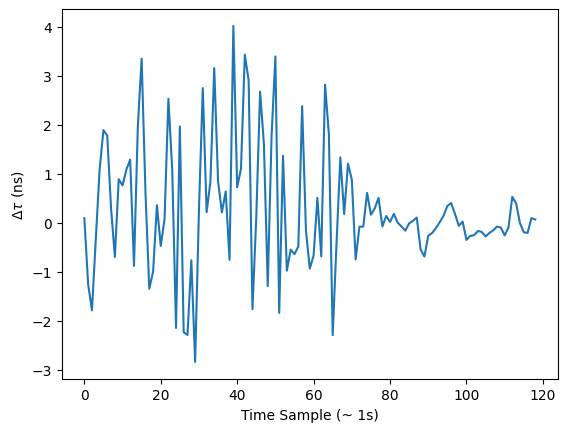

In [79]:
plt.plot(np.diff(taus_small[:, 5]))
plt.xlabel('Time Sample (~ 1s)')
plt.ylabel(r'$\Delta \tau$ (ns)')

In [64]:
#do we need to unwrap???
# have the option to use either to get the final proper offset value.
#taus_unwrapped = np.unwrap(np.angle(np.exp(1j*taus_fitted.reshape(-1,nant_used-1)*2*np.pi*freqs_normalized.mean())),axis=0)/(2*np.pi*freqs_normalized.mean())

# plot the relative delays of the other antenna with respect to the reference antenna
# plt.plot(taus_unwrapped,label=labels)
# plt.ylabel('Relative Delay (ns)')
# plt.xlabel('Time (s)')
# plt.legend(loc='upper right')
# plt.suptitle('Unwrapped Taus')

21


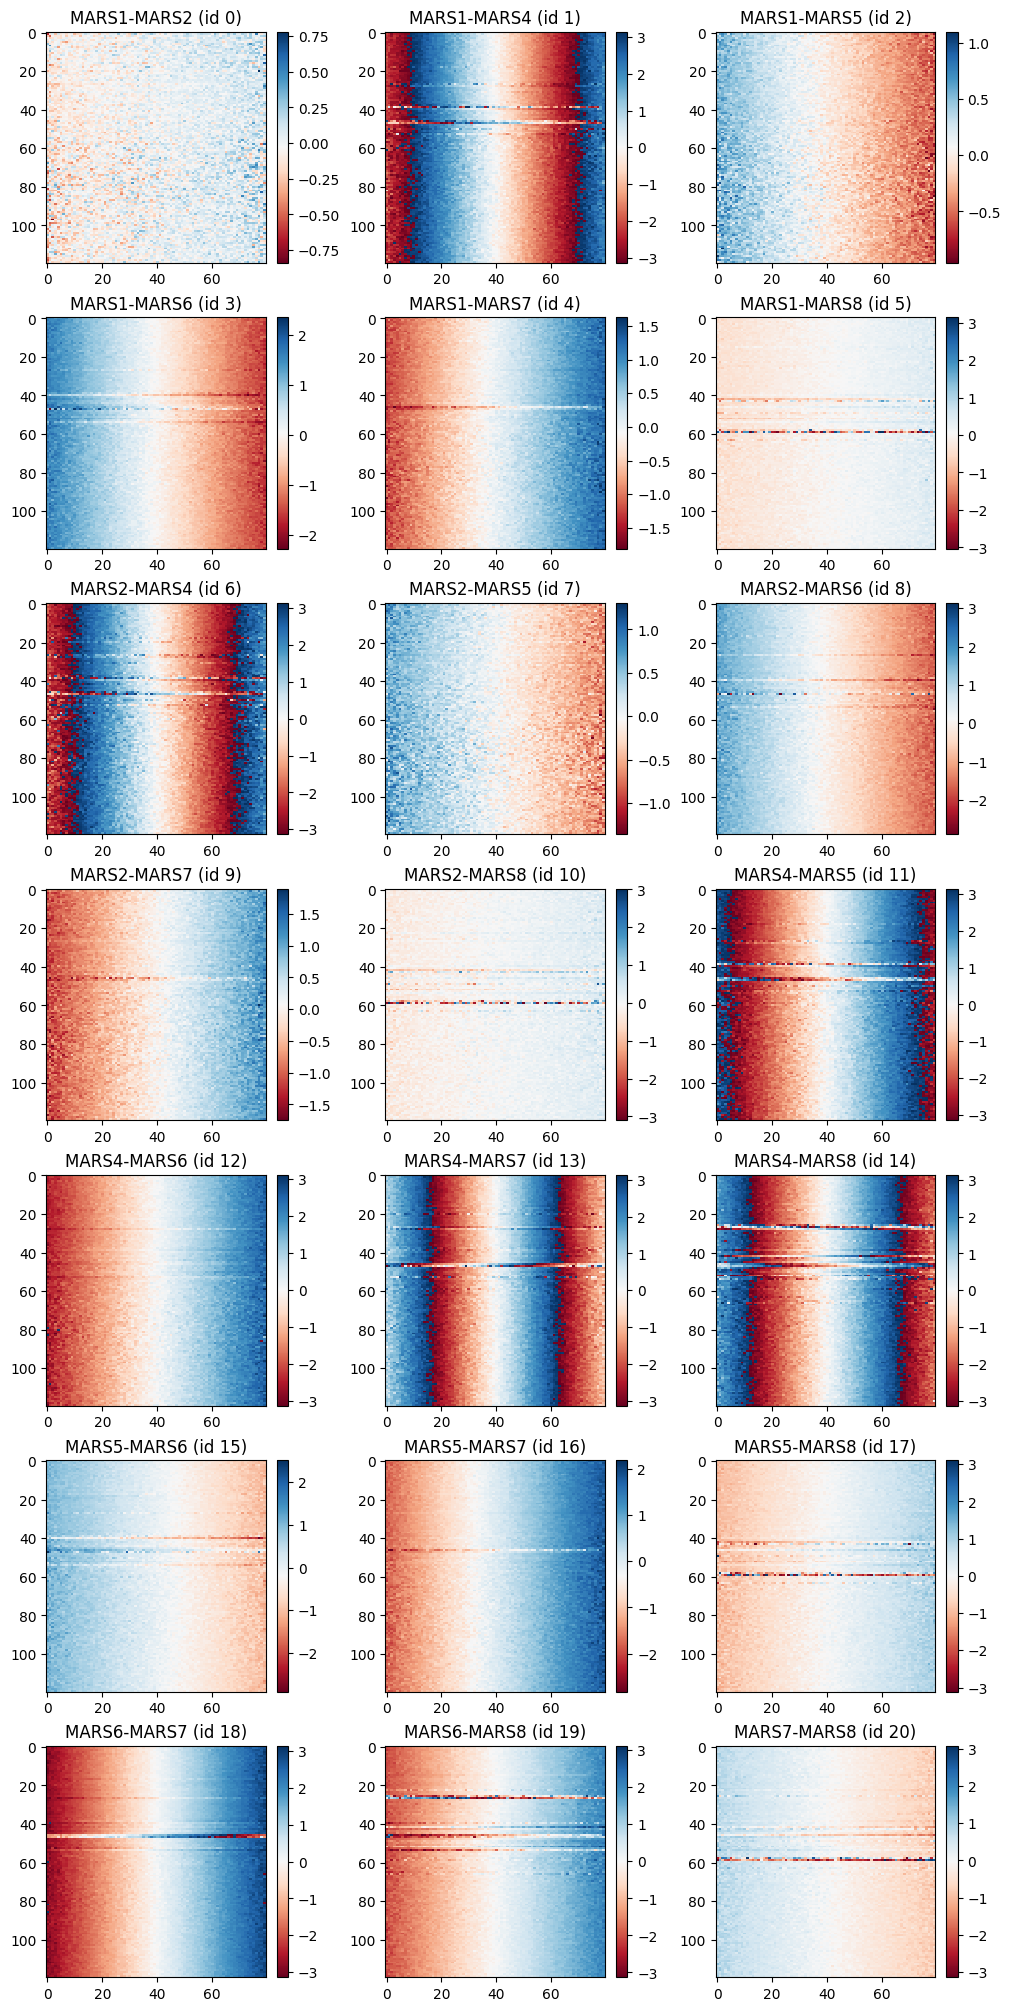

In [53]:
#generate aligned phase plots for each baseline with fitted taus
#in the meantime also phases the visibilities to align them

antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(7,3, constrained_layout=True)
fig.set_size_inches(10,20)
ax=np.ravel(ax)

blnum=0
print(n_blines)
x = np.arange(nchans)
phased_vis = np.empty_like(vis2[:,:,:])
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            if i==0:
                tau1=0
            else:
                tau1 = taus_unwrapped[:,i-1]
            tau2 = taus_unwrapped[:,j-1]
            rel_delay = tau1-tau2
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            phased_vis[blnum,:,:] = vis2[blnum,:,:]*np.exp(-2j*np.pi*freqs_normalized[None,:]*rel_delay[:,None])
            if masking:
                phased_vis_masked = np.ma.masked_where(mask2, np.angle(phased_vis[blnum,:,:]))
                img = ax[blnum].imshow(phased_vis_masked, aspect='auto', interpolation='none', cmap='RdBu')
                cbar=plt.colorbar(img,ax=ax[blnum])
            else:
                img=ax[blnum].imshow(np.angle(phased_vis[blnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
                cbar=plt.colorbar(img,ax=ax[blnum])
            blnum+=1
# plt.tight_layout()

(80, 21)
[[0.00816903 0.01402661 0.00814526 0.00702465 0.00743187 0.00865771
  0.01693254 0.01044332 0.00998362 0.01051746 0.01016467 0.01305731
  0.0121318  0.01214748 0.01269953 0.00814341 0.00825869 0.00854259
  0.00714547 0.00939401 0.00797971]]


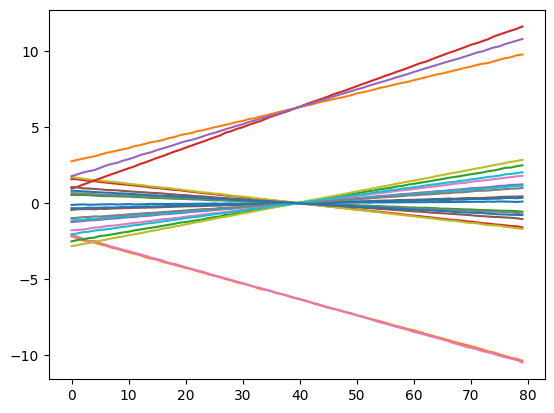

In [54]:
#take average across time once aligned to boost SNR
if masking:
    #introduce mask 3 or something to check if there are enough points ALONG TIME. 
    #if bad, just interpolate after the fact and assign high noise value
    phased_vis_masked = np.ma.array(phased_vis, mask=np.broadcast_to(mask2[None, :, :], phased_vis.shape))
    avg_multi_vis = phased_vis_masked.mean(axis=1)
else:
    avg_multi_vis = np.mean(phased_vis, axis=1)


#avg_multi_vis = np.mean(phased_vis,axis=1)
# avg_multi_vis = np.median(phased_vis,axis=1)

#now have very clean phase ramp with super low noise
avg_multi_vis = avg_multi_vis.T.copy()
plt.plot(np.unwrap(np.angle(avg_multi_vis),axis=0))
print(avg_multi_vis.shape)


#get that noise by fitting a line and getting std of residuals
noise_matrix_avg = np.zeros((1,n_blines),dtype='float64')
for bl in range(n_blines):
    y = np.unwrap(np.angle(avg_multi_vis[:,bl]))
    m, c = np.polyfit(x,y, 1)
    residual = y - (m*x + c)
    noise_matrix_avg[0,bl] = np.std(residual)
print(noise_matrix_avg)

In [ ]:
ntime2=1
nant=7
nbl=nant*(nant-1)//2

#can now just fit linearly using normal equations
data_matrix = np.unwrap(np.angle(avg_multi_vis),axis=0)
data_matrix = data_matrix.reshape(ntime2,nchans,nblines)

Ag = hf.get_grammian(nant)
print(data_matrix.shape)

AtA2,Atd2 = hf.get_AtA_Atd(data_matrix,
                            Ag,
                            noise_matrix_avg**2,
                            freqs_normalized,
                            nant,
                            nchans,
                            ntime2,
                            fit_constant=True)

AtA_inv2 = np.linalg.inv(AtA2)

mfit2 = AtA_inv2 @ Atd2
print(mfit2)
# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
tau_linear2 = mfit2[:ntime2 * bs]
phi_linear2 = mfit2[ntime2 * bs:]
errs_all = np.sqrt(np.diag(AtA_inv2))
print(tau_linear2)
print('test')

taus_fitted_all = tau_linear2[:, np.newaxis] + taus_unwrapped.T
taus_errs_all = errs_all[:nant-1]
print(errs_all)

(1, 80, 21)
Snu 69.3160377990881 Snu2 60.05891523378247
[ -4.74322713  57.13955261  28.15784402  28.34496582   0.8681731
 -53.32387386   4.10977812 -49.50763381 -24.3973186  -24.55935049
  -0.75377732  46.20338099]
[ -4.74322713  57.13955261  28.15784402  28.34496582   0.8681731
 -53.32387386]
test
[3.98024545 4.96291672 3.71940354 3.52770322 3.55876116 3.80112628
 3.4486856  4.30012159 3.22267899 3.05658016 3.08349033 3.29348771]


In [ ]:
# with h5py.File('finetiming_dump1.h5', 'a') as f:
#     ds = f.create_dataset(fname_data, data=taus_fitted_all)
#     ds.attrs['starting_specnum'] = pulse_start_spec_cut